# Desenho e aleatorização

**Tema:** Estatística › A/B Testing e Desenho Experimental

A maior parte dos experimentos que dão resultado errado **não erra na análise**
— erra antes, no desenho. Este notebook trata das decisões que acontecem antes
de o primeiro usuário entrar no teste: unidade de aleatorização, como sortear,
como dimensionar, e como verificar que a aleatorização de fato funcionou.

> **A ideia central:** aleatorizar é a única técnica que controla confundidores
> que você **não mediu** — e por isso é a única que sustenta uma afirmação
> causal sem suposições heroicas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(20240)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Por que aleatorizar: o confundidor que você não mediu

**Cenário:** um app lança um recurso novo. Comparando quem usou com quem não
usou, o recurso parece aumentar a retenção em 20 pontos percentuais.

O problema: quem escolhe usar um recurso novo já era mais engajado. Vamos
construir a população com o confundidor **explícito** e ver os dois números
lado a lado.

In [2]:
N = 40_000
engajamento = rng.beta(2, 5, N)          # o confundidor: propensão de base do usuário

# adoção ESPONTÂNEA depende do engajamento — é aí que nasce o viés
adotou = rng.random(N) < (0.05 + 0.75 * engajamento)

EFEITO_REAL = 0.03                        # o recurso vale 3 pontos percentuais, só isso
p_retencao = np.clip(0.15 + 0.65 * engajamento + EFEITO_REAL * adotou, 0, 1)
reteve = rng.random(N) < p_retencao

obs = pd.DataFrame({"engajamento": engajamento, "adotou": adotou, "reteve": reteve})
dif_observacional = obs.loc[obs.adotou, "reteve"].mean() - obs.loc[~obs.adotou, "reteve"].mean()

print(f"retenção de quem ADOTOU     : {obs.loc[obs.adotou, 'reteve'].mean():.4f}")
print(f"retenção de quem NÃO adotou : {obs.loc[~obs.adotou, 'reteve'].mean():.4f}")
print(f"\ndiferença observacional     : {dif_observacional:+.4f}")
print(f"efeito causal REAL          : {EFEITO_REAL:+.4f}")
print(f"exagero                     : {dif_observacional / EFEITO_REAL:.1f}x")

retenção de quem ADOTOU     : 0.4100
retenção de quem NÃO adotou : 0.3207

diferença observacional     : +0.0893
efeito causal REAL          : +0.0300
exagero                     : 3.0x


Agora o mesmo mundo, com **aleatorização**. Ninguém escolhe: o sorteio decide.

diferença experimental      : +0.0245
efeito causal REAL          : +0.0300


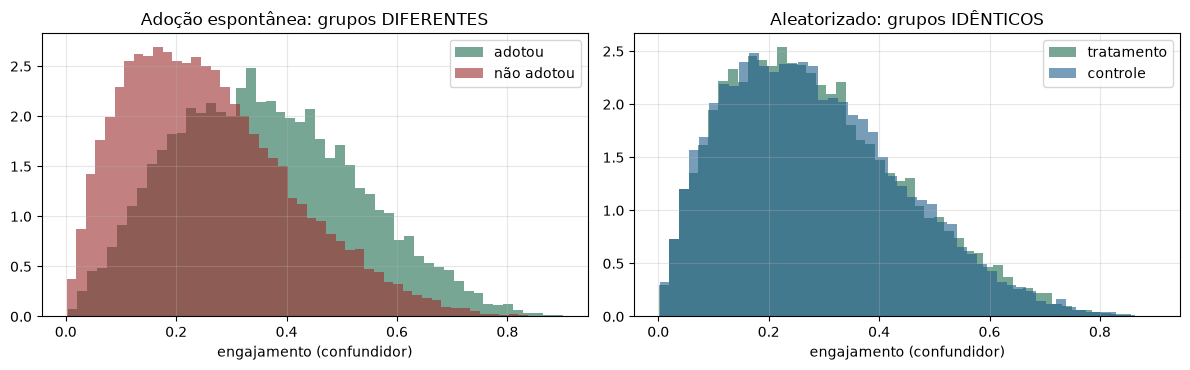

In [3]:
grupo = rng.random(N) < 0.5              # sorteio puro, independente de tudo
p_ret_exp = np.clip(0.15 + 0.65 * engajamento + EFEITO_REAL * grupo, 0, 1)
reteve_exp = rng.random(N) < p_ret_exp

dif_experimental = reteve_exp[grupo].mean() - reteve_exp[~grupo].mean()
print(f"diferença experimental      : {dif_experimental:+.4f}")
print(f"efeito causal REAL          : {EFEITO_REAL:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(obs.loc[obs.adotou, "engajamento"], bins=50, alpha=0.6, color=VERDE,
             density=True, label="adotou")
axes[0].hist(obs.loc[~obs.adotou, "engajamento"], bins=50, alpha=0.6, color=VERMELHO,
             density=True, label="não adotou")
axes[0].set_title("Adoção espontânea: grupos DIFERENTES")
axes[0].set_xlabel("engajamento (confundidor)"); axes[0].legend()

axes[1].hist(engajamento[grupo], bins=50, alpha=0.6, color=VERDE, density=True,
             label="tratamento")
axes[1].hist(engajamento[~grupo], bins=50, alpha=0.6, color=AZUL, density=True,
             label="controle")
axes[1].set_title("Aleatorizado: grupos IDÊNTICOS")
axes[1].set_xlabel("engajamento (confundidor)"); axes[1].legend()
plt.tight_layout(); plt.show()

O painel da esquerda é o problema inteiro em uma imagem: as duas distribuições
de engajamento são completamente diferentes, então a comparação de retenção
mede **as pessoas**, não o recurso.

À direita, o sorteio produziu duas distribuições sobrepostas — e não só em
engajamento: **em toda variável imaginável**, medida ou não. É isso que nenhum
ajuste estatístico consegue garantir.

## 2. A unidade de aleatorização

Aleatorizar por **sessão** quando o efeito é por **usuário** produz duas
doenças: inconsistência visível para a pessoa, e correlação intra-usuário que
infla a significância.

In [4]:
N_USUARIOS = 3_000
sessoes_por_usuario = rng.poisson(6, N_USUARIOS) + 1

# cada usuário tem seu próprio nível de base — é a fonte da correlação intra-usuário
nivel_usuario = rng.normal(0, 1.2, N_USUARIOS)

id_usuario = np.repeat(np.arange(N_USUARIOS), sessoes_por_usuario)
base = np.repeat(nivel_usuario, sessoes_por_usuario)
n_sessoes = len(id_usuario)

# aleatorização POR SESSÃO (errada aqui)
g_sessao = rng.random(n_sessoes) < 0.5
# aleatorização POR USUÁRIO (correta)
g_usuario = np.repeat(rng.random(N_USUARIOS) < 0.5, sessoes_por_usuario)

# NENHUM efeito real — qualquer "significância" abaixo é falsa
y = base + rng.normal(0, 1, n_sessoes)

p_sessao = stats.ttest_ind(y[g_sessao], y[~g_sessao]).pvalue
p_usuario_ingenuo = stats.ttest_ind(y[g_usuario], y[~g_usuario]).pvalue

# análise correta: agregue por usuário ANTES de testar
agg = pd.DataFrame({"u": id_usuario, "y": y, "g": g_usuario}).groupby("u").agg(
    y=("y", "mean"), g=("g", "first"))
p_usuario_correto = stats.ttest_ind(agg.loc[agg.g, "y"], agg.loc[~agg.g, "y"]).pvalue

print(f"unidades: {N_USUARIOS} usuários, {n_sessoes} sessões\n")
print(f"aleatorizado por sessão, testado por sessão   p = {p_sessao:.4f}")
print(f"aleatorizado por usuário, testado por sessão  p = {p_usuario_ingenuo:.4f}")
print(f"aleatorizado por usuário, AGREGADO por usuário p = {p_usuario_correto:.4f}")
print("\n(não há efeito nenhum: todos deveriam ser p-valores 'grandes')")

unidades: 3000 usuários, 21065 sessões

aleatorizado por sessão, testado por sessão   p = 0.7491
aleatorizado por usuário, testado por sessão  p = 0.8983
aleatorizado por usuário, AGREGADO por usuário p = 0.6894

(não há efeito nenhum: todos deveriam ser p-valores 'grandes')


Um p-valor isolado não prova nada — vamos medir a **taxa de falso positivo** de
cada abordagem, repetindo o experimento nulo muitas vezes.

In [5]:
def taxa_falso_positivo(n_experimentos=400):
    contadores = {"por sessão (unidade errada)": 0,
                  "por usuário, teste por sessão": 0,
                  "por usuário, agregado": 0}
    for _ in range(n_experimentos):
        spu = rng.poisson(6, 800) + 1
        nivel = rng.normal(0, 1.2, 800)
        uid = np.repeat(np.arange(800), spu)
        b = np.repeat(nivel, spu)
        yy = b + rng.normal(0, 1, len(uid))

        gs = rng.random(len(uid)) < 0.5
        gu = np.repeat(rng.random(800) < 0.5, spu)

        contadores["por sessão (unidade errada)"] += stats.ttest_ind(yy[gs], yy[~gs]).pvalue < 0.05
        contadores["por usuário, teste por sessão"] += stats.ttest_ind(yy[gu], yy[~gu]).pvalue < 0.05
        a = pd.DataFrame({"u": uid, "y": yy, "g": gu}).groupby("u").agg(
            y=("y", "mean"), g=("g", "first"))
        contadores["por usuário, agregado"] += stats.ttest_ind(
            a.loc[a.g, "y"], a.loc[~a.g, "y"]).pvalue < 0.05
    return {k: v / n_experimentos for k, v in contadores.items()}


for nome, taxa in taxa_falso_positivo().items():
    marca = "OK " if abs(taxa - 0.05) < 0.025 else "!! "
    print(f"{marca}{nome:<34s} falso positivo = {taxa:.3f}  (nominal 0,05)")

OK por sessão (unidade errada)        falso positivo = 0.050  (nominal 0,05)
!! por usuário, teste por sessão      falso positivo = 0.380  (nominal 0,05)
OK por usuário, agregado              falso positivo = 0.052  (nominal 0,05)


**O diagnóstico:** aleatorizar por usuário e testar por sessão infla o erro
tipo I bem acima de 5%, porque as sessões do mesmo usuário **não são
independentes** — o teste acha que tem muito mais informação do que realmente
tem.

**A regra:** a unidade de **análise** deve ser a unidade de **aleatorização**.
Se você sorteou usuários, agregue por usuário antes de testar (ou use erros-
padrão agrupados / delta method para métricas de razão).

## 3. Aleatorização por hash: determinística e reprodutível

Em produção você não sorteia com um gerador aleatório a cada requisição — o
usuário precisa cair sempre no mesmo grupo. A técnica padrão é **hash do
identificador + sal do experimento**.

In [6]:
import hashlib


def atribui(id_usuario, nome_experimento, pesos=(0.5, 0.5), variantes=("A", "B")):
    """Atribuição determinística: mesmo usuário -> sempre a mesma variante."""
    chave = f"{nome_experimento}:{id_usuario}".encode()
    digest = hashlib.sha256(chave).hexdigest()
    u = int(digest[:16], 16) / float(1 << 64)          # uniforme em [0,1)
    limites = np.cumsum(pesos)
    return variantes[int(np.searchsorted(limites, u))]


ids = [f"user_{i}" for i in range(60_000)]
exp1 = np.array([atribui(i, "checkout_v2") for i in ids])
exp2 = np.array([atribui(i, "banner_natal") for i in ids])

print("experimento 1 —", dict(zip(*np.unique(exp1, return_counts=True))))
print("experimento 2 —", dict(zip(*np.unique(exp2, return_counts=True))))
print(f"\nmesmo usuário, mesma resposta? "
      f"{atribui('user_42', 'checkout_v2') == atribui('user_42', 'checkout_v2')}")
print(f"correlação entre os dois experimentos: "
      f"{np.corrcoef(exp1 == 'A', exp2 == 'A')[0,1]:+.5f}  (deve ser ~0)")

# alocação desigual, para rampa de exposição
rampa = np.array([atribui(i, "feature_arriscada", pesos=(0.9, 0.1)) for i in ids])
print("\nrampa 90/10 —", dict(zip(*np.unique(rampa, return_counts=True))))

experimento 1 — {np.str_('A'): np.int64(30022), np.str_('B'): np.int64(29978)}
experimento 2 — {np.str_('A'): np.int64(29918), np.str_('B'): np.int64(30082)}

mesmo usuário, mesma resposta? True
correlação entre os dois experimentos: -0.00433  (deve ser ~0)



rampa 90/10 — {np.str_('A'): np.int64(54055), np.str_('B'): np.int64(5945)}


**Os três requisitos que o hash resolve de uma vez:**

1. **Determinismo** — o usuário vê sempre a mesma versão, entre sessões e
   dispositivos (desde que o id seja estável).
2. **Independência entre experimentos** — o sal (`nome_experimento`) garante
   que quem caiu em B no teste 1 não tem viés para B no teste 2. Sem o sal,
   experimentos simultâneos ficam correlacionados e se contaminam.
3. **Sem estado** — não é preciso guardar tabela de atribuição; qualquer
   serviço recalcula a mesma resposta.

## 4. Dimensionamento: quanto tráfego este experimento custa

métrica                           MDE      n/grupo    dias
------------------------------------------------------------
conversão 12%                     2%      290,273    14.5
conversão 12%                     5%       47,036     2.4
conversão 12%                    10%       12,004     0.6
conversão 3%                      5%      207,938    10.4
receita/usuário (dp 85)           R$2       28,355     1.4


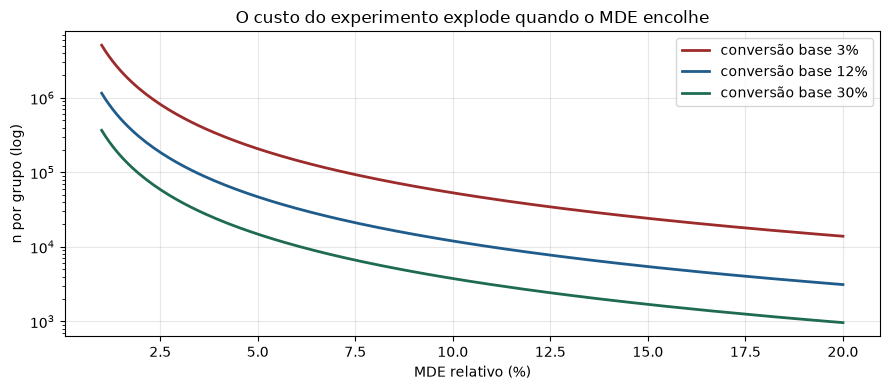

In [7]:
def n_por_grupo_proporcao(p0, mde_relativo, alfa=0.05, poder=0.80):
    p1 = p0 * (1 + mde_relativo)
    z_a, z_b = stats.norm.isf(alfa / 2), stats.norm.isf(1 - poder)
    p_barra = (p0 + p1) / 2
    num = (z_a * np.sqrt(2 * p_barra * (1 - p_barra))
           + z_b * np.sqrt(p0 * (1 - p0) + p1 * (1 - p1))) ** 2
    return int(np.ceil(num / (p1 - p0) ** 2))


def n_por_grupo_media(desvio, mde_absoluto, alfa=0.05, poder=0.80):
    z_a, z_b = stats.norm.isf(alfa / 2), stats.norm.isf(1 - poder)
    return int(np.ceil(2 * desvio**2 * (z_a + z_b) ** 2 / mde_absoluto**2))


TRAFEGO_DIARIO = 40_000
print(f"{'métrica':<28s} {'MDE':>8s} {'n/grupo':>12s} {'dias':>7s}")
print("-" * 60)
for p0, mde in [(0.12, 0.02), (0.12, 0.05), (0.12, 0.10), (0.03, 0.05)]:
    n = n_por_grupo_proporcao(p0, mde)
    print(f"{'conversão ' + f'{p0:.0%}':<28s} {mde:>7.0%} {n:>12,} "
          f"{2*n/TRAFEGO_DIARIO:>7.1f}")
n_receita = n_por_grupo_media(desvio=85.0, mde_absoluto=2.0)
print(f"{'receita/usuário (dp 85)':<28s} {'R$2':>8s} {n_receita:>12,} "
      f"{2*n_receita/TRAFEGO_DIARIO:>7.1f}")

fig, ax = plt.subplots(figsize=(9, 4))
mdes = np.linspace(0.01, 0.20, 200)
for p0, cor in [(0.03, VERMELHO), (0.12, AZUL), (0.30, VERDE)]:
    ns = [n_por_grupo_proporcao(p0, m) for m in mdes]
    ax.plot(mdes * 100, ns, lw=2, color=cor, label=f"conversão base {p0:.0%}")
ax.set_yscale("log"); ax.set_xlabel("MDE relativo (%)"); ax.set_ylabel("n por grupo (log)")
ax.set_title("O custo do experimento explode quando o MDE encolhe")
ax.legend(); plt.tight_layout(); plt.show()

**A leitura que muda conversas:** detectar 2% de lift relativo custa ~25x mais
tráfego que detectar 10%. O gráfico em escala log é uma reta descendente — o
custo é $\propto 1/\Delta^2$.

**O MDE é uma decisão de negócio, não estatística.** A pergunta certa é: "qual
o menor ganho que justificaria implantar e manter essa mudança?" Se a resposta
é 5%, dimensionar para 1% é queimar semanas de tráfego para responder uma
pergunta que ninguém faria.

## 5. Sample Ratio Mismatch: o primeiro teste, sempre

In [8]:
def checa_srm(contagens, esperado=None, alfa=0.001):
    contagens = np.asarray(contagens, dtype=float)
    n = contagens.sum()
    esperado = np.full_like(contagens, 1 / len(contagens)) if esperado is None \
        else np.asarray(esperado, dtype=float)
    esperados = esperado * n
    qui2 = (((contagens - esperados) ** 2) / esperados).sum()
    p = 1 - stats.chi2.cdf(qui2, len(contagens) - 1)
    ok = p >= alfa
    print(f"observado {contagens.astype(int)}  esperado {esperados.round(0).astype(int)}")
    print(f"proporção observada: {(contagens/n).round(5)}")
    print(f"χ² = {qui2:.3f}   p = {p:.2e}   -> "
          f"{'OK, pode analisar' if ok else 'SRM! NÃO ANALISE ESTE EXPERIMENTO'}\n")
    return ok


print(">>> caso 1: experimento saudável")
checa_srm([99_812, 100_188])

print(">>> caso 2: desbalanceamento de 0,4% — parece nada, é fatal")
checa_srm([100_800, 99_200])

print(">>> caso 3: amostra pequena, mesmo desbalanceamento relativo")
checa_srm([1_008, 992])

>>> caso 1: experimento saudável
observado [ 99812 100188]  esperado [100000 100000]
proporção observada: [0.49906 0.50094]
χ² = 0.707   p = 4.00e-01   -> OK, pode analisar

>>> caso 2: desbalanceamento de 0,4% — parece nada, é fatal
observado [100800  99200]  esperado [100000 100000]
proporção observada: [0.504 0.496]
χ² = 12.800   p = 3.47e-04   -> SRM! NÃO ANALISE ESTE EXPERIMENTO

>>> caso 3: amostra pequena, mesmo desbalanceamento relativo
observado [1008  992]  esperado [1000 1000]
proporção observada: [0.504 0.496]
χ² = 0.128   p = 7.21e-01   -> OK, pode analisar



np.True_

**O caso 2 é o que engana.** 50,4% contra 49,6% parece ruído — mas com 200 mil
usuários, o desvio-padrão da proporção é 0,11 p.p., e 0,4 p.p. está a quase 4
desvios. A probabilidade disso ser acaso é da ordem de $10^{-4}$.

**Por que $\alpha = 0{,}001$ e não 0,05:** o teste de SRM roda em todo
experimento, então usar 5% geraria um alarme falso a cada 20 testes. O limiar
severo mantém o alarme confiável.

> **Não existe correção estatística para SRM.** O desbalanceamento significa
> que usuários foram perdidos ou duplicados de forma não aleatória, e você não
> sabe quem. As causas típicas: bots concentrados em uma variante, redirect que
> perde usuários, SDK que falha em uma versão do app, filtro aplicado depois da
> aleatorização. Ache a causa e refaça.

## 6. Teste A/A: validando a infraestrutura

Rode a mesma versão contra ela mesma. Se a infraestrutura estiver correta, os
p-valores devem ser uniformes e ~5% deles cairão abaixo de 0,05 — nem mais,
nem menos.

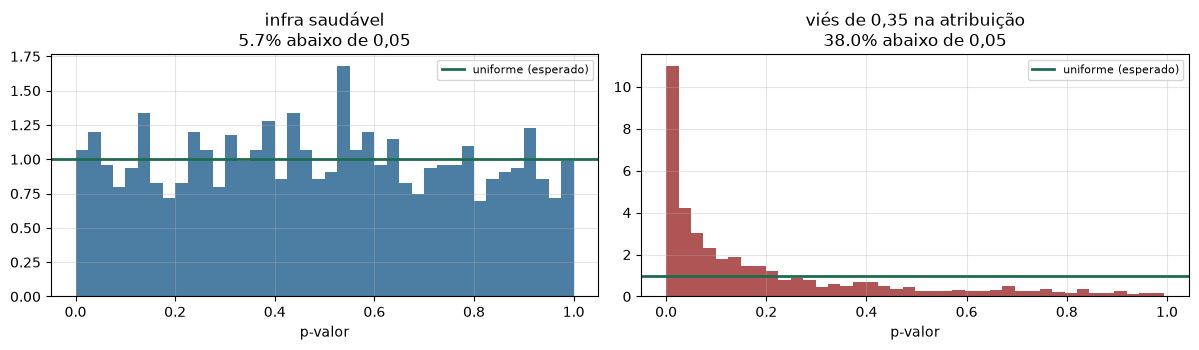

A/A saudável : 0.057 de falsos positivos (esperado 0,05)
A/A viciado  : 0.380  <- a infraestrutura está errada


In [9]:
def roda_aa(n_por_grupo=5000, n_experimentos=1500, correlacao_espuria=0.0):
    ps = []
    for _ in range(n_experimentos):
        a = rng.normal(50, 10, n_por_grupo)
        b = rng.normal(50 + correlacao_espuria, 10, n_por_grupo)
        ps.append(stats.ttest_ind(a, b).pvalue)
    return np.array(ps)


p_sadio = roda_aa()
p_viciado = roda_aa(correlacao_espuria=0.35)   # um viés minúsculo na atribuição

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, ps, titulo, cor in [(axes[0], p_sadio, "infra saudável", AZUL),
                            (axes[1], p_viciado, "viés de 0,35 na atribuição", VERMELHO)]:
    ax.hist(ps, bins=40, density=True, color=cor, alpha=0.8)
    ax.axhline(1.0, color=VERDE, lw=2, label="uniforme (esperado)")
    ax.set_title(f"{titulo}\n{(ps < 0.05).mean():.1%} abaixo de 0,05")
    ax.set_xlabel("p-valor"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"A/A saudável : {(p_sadio < 0.05).mean():.3f} de falsos positivos (esperado 0,05)")
print(f"A/A viciado  : {(p_viciado < 0.05).mean():.3f}  <- a infraestrutura está errada")

**O A/A é o teste do teste.** Ele não valida a sua hipótese de produto — valida
a atribuição, o logging, a definição da métrica e o pipeline de análise. Times
maduros mantêm um A/A rodando **permanentemente** em paralelo, como um canário.

Um viés de 0,35 em uma métrica com desvio 10 é 3,5% de efeito — invisível a
olho nu e suficiente para produzir "descobertas" o ano inteiro.

## 7. Aleatorização estratificada: não torça pelo balanceamento

Aleatorização simples **tende** a balancear, mas com amostra moderada os
desequilíbrios acontecem. Estratificar garante o balanceamento nas variáveis
que você sabe que importam.

In [10]:
N_EXP = 2_000
plataforma = rng.choice(["iOS", "Android", "Web"], N_EXP, p=[0.35, 0.45, 0.20])

# simples
g_simples = rng.random(N_EXP) < 0.5

# estratificada: sorteia DENTRO de cada estrato
g_estrat = np.zeros(N_EXP, dtype=bool)
for estrato in np.unique(plataforma):
    idx = np.where(plataforma == estrato)[0]
    embaralhado = rng.permutation(idx)
    g_estrat[embaralhado[: len(idx) // 2]] = True

comparacao = pd.DataFrame({
    "simples (trat.)": [g_simples[plataforma == e].mean() for e in np.unique(plataforma)],
    "estratificada (trat.)": [g_estrat[plataforma == e].mean() for e in np.unique(plataforma)],
}, index=np.unique(plataforma))
print(comparacao.round(4).to_string(), "\n")

# quão frequente é um desequilíbrio relevante com aleatorização simples?
desequilibrios = []
for _ in range(3000):
    g = rng.random(N_EXP) < 0.5
    fracoes = [g[plataforma == e].mean() for e in np.unique(plataforma)]
    desequilibrios.append(max(abs(np.array(fracoes) - 0.5)))
desequilibrios = np.array(desequilibrios)
print(f"aleatorização simples, n = {N_EXP}:")
print(f"  desequilíbrio máximo mediano: {np.median(desequilibrios):.4f}")
print(f"  P(algum estrato desviar > 3 p.p.): {(desequilibrios > 0.03).mean():.1%}")
print(f"  P(algum estrato desviar > 5 p.p.): {(desequilibrios > 0.05).mean():.1%}")

         simples (trat.)  estratificada (trat.)
Android           0.4989                    0.5
Web               0.4747                    0.5
iOS               0.4688                    0.5 



aleatorização simples, n = 2000:
  desequilíbrio máximo mediano: 0.0253
  P(algum estrato desviar > 3 p.p.): 34.5%
  P(algum estrato desviar > 5 p.p.): 5.8%


**Quando estratificar vale a pena:** quando a variável explica muito da
métrica (plataforma quase sempre explica) e a amostra não é gigantesca. Além de
garantir o balanceamento, a estratificação **reduz variância** — é prima do
CUPED, assunto do notebook 03.

**Quando não vale:** com milhões de usuários, a aleatorização simples balanceia
tudo sozinha, e a complexidade operacional de estratificar não se paga.

## O que levar deste notebook

- **Aleatorizar controla o que você não mediu** — nenhum ajuste estatístico faz isso.
- A **unidade de análise deve ser a unidade de aleatorização**; testar sessões
  de usuários sorteados infla o erro tipo I.
- Use **hash + sal do experimento**: determinístico, sem estado e independente
  entre experimentos simultâneos.
- **MDE é decisão de negócio.** O custo cresce com $1/\Delta^2$.
- **Cheque SRM antes de tudo**, com $\alpha = 0{,}001$. SRM não tem conserto.
- **Rode A/A** para validar infraestrutura — de preferência continuamente.
- **Estratifique** nas variáveis que importam em vez de torcer pelo sorteio.

→ No próximo notebook: a análise ponta a ponta de um A/B, incluindo métricas de
razão, guardrails e heterogeneidade.